In [1]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("images_xor", exist_ok=True)

In [3]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

X_bias = np.c_[np.ones(len(X)), X]

print("Input:")
print(X)

print("\nOutput:")
print(y)

Input:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Output:
[0 1 1 0]


In [4]:
np.random.seed(42)
weights_input_hidden = np.random.uniform(-1, 1, (3, 2))
weights_hidden_output = np.random.uniform(-1, 1, (3, 1))

learning_rate = 0.5
epochs = 1000


In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [6]:
def plot_boundary(epoch):
    plt.figure(figsize=(6,6))
    for i, point in enumerate(X):
        color = "red" if y[i] == 1 else "blue"
        plt.scatter(point[0], point[1], c=color, s=150)
        plt.text(point[0]+0.03, point[1]+0.03, str(y[i]))

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_bias = np.c_[np.ones(len(grid)), grid]
    
    hidden_out = sigmoid(np.dot(grid_bias, weights_input_hidden))
    hidden_out_bias = np.c_[np.ones(len(hidden_out)), hidden_out]
    Z = sigmoid(np.dot(hidden_out_bias, weights_hidden_output))
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
    plt.contour(xx, yy, Z, levels=[0.5], colors='black')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"Epoch {epoch}")
    plt.grid()
    filename = f"images_xor/update_{epoch}.png"
    plt.savefig(filename, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

Epoch 0, Errors: 2


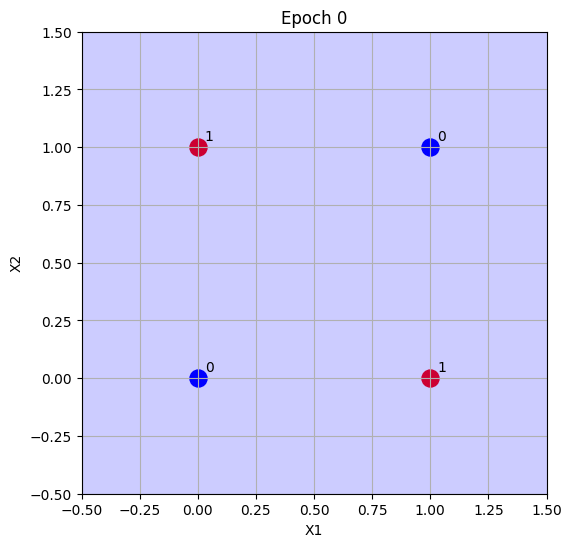

Epoch 100, Errors: 3


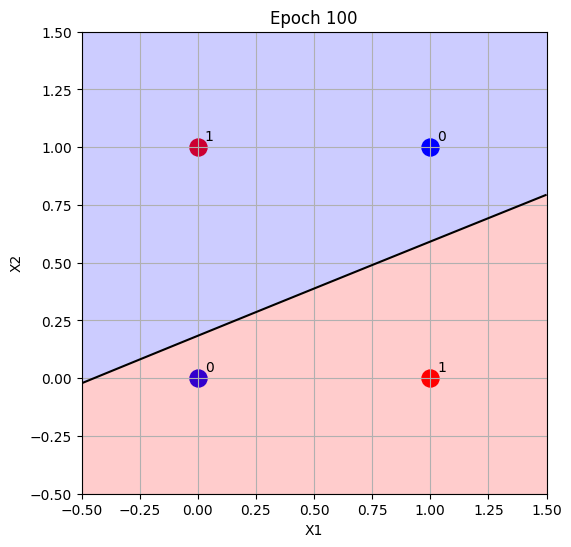

Epoch 200, Errors: 2


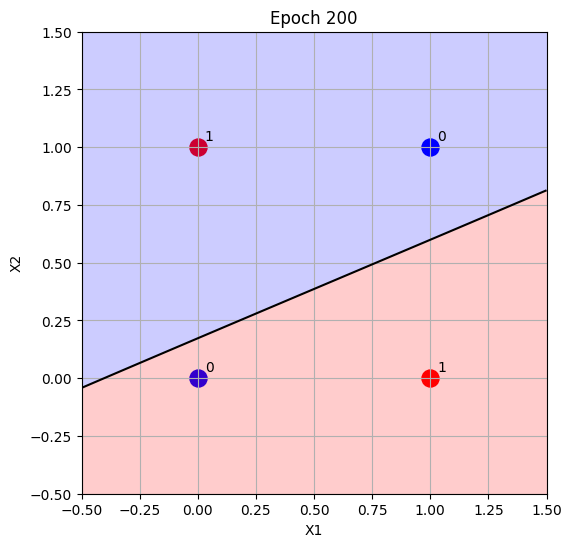

Epoch 300, Errors: 2


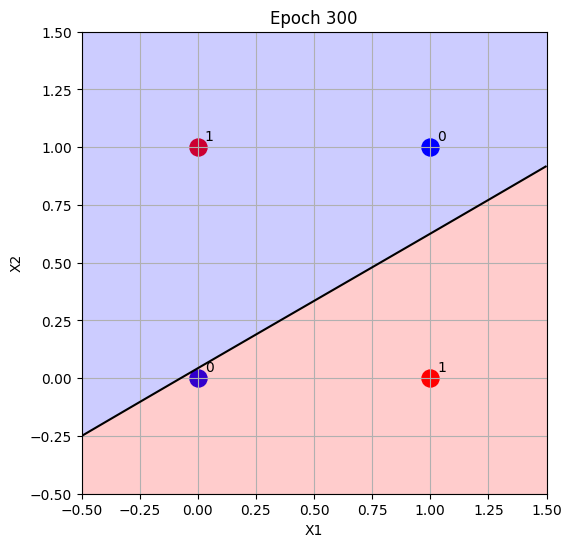

Epoch 400, Errors: 1


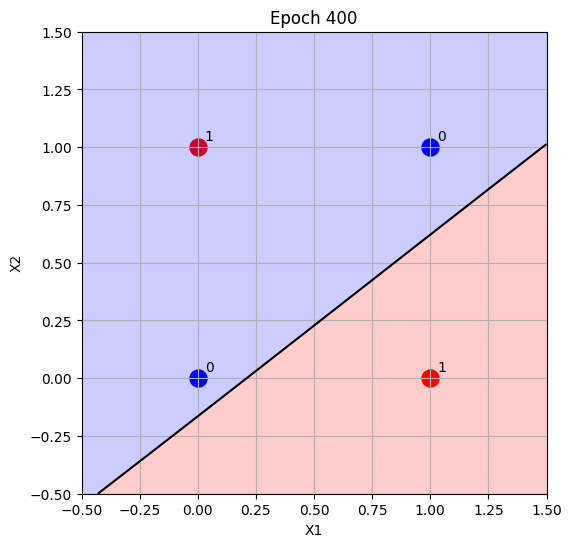

Epoch 500, Errors: 1


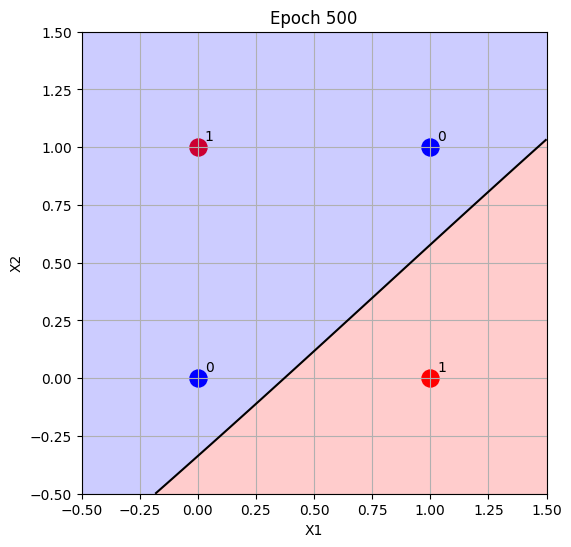

Epoch 600, Errors: 1


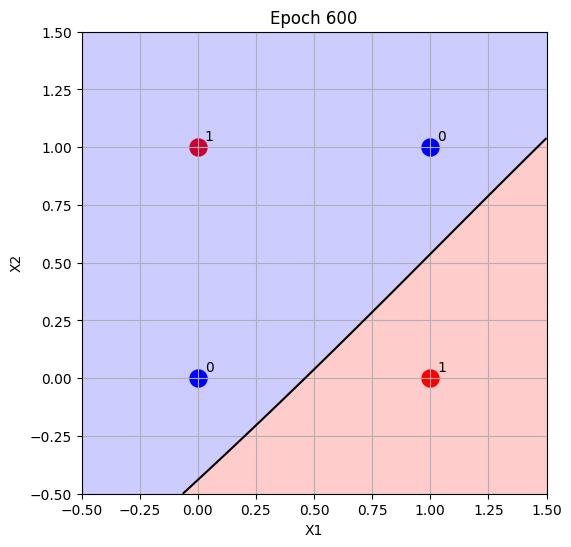

Epoch 700, Errors: 1


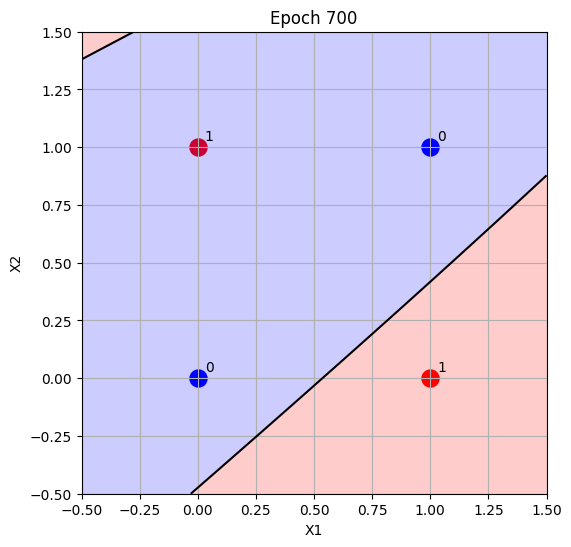

Converged at epoch 744


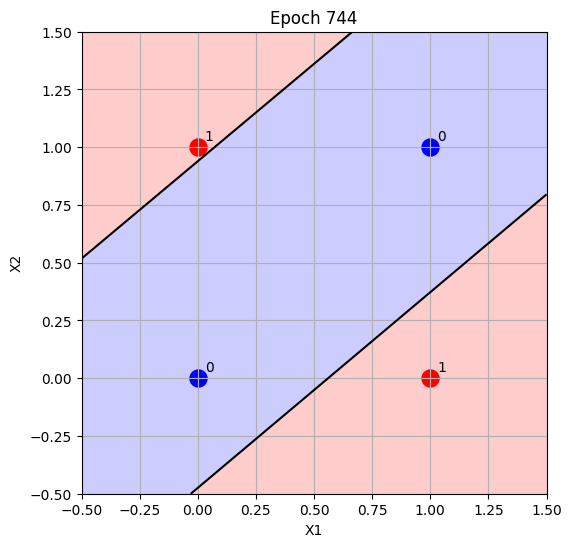

In [7]:
for epoch in range(epochs):
    errors = 0
    for i in range(len(X_bias)):
        # Forward pass
        hidden_input = np.dot(X_bias[i], weights_input_hidden)
        hidden_output = sigmoid(hidden_input)
        hidden_output_bias = np.insert(hidden_output, 0, 1)
        
        final_input = np.dot(hidden_output_bias, weights_hidden_output)
        prediction = sigmoid(final_input)
        
        # Error
        error = y[i] - prediction
        if (prediction >= 0.5 and y[i] == 0) or (prediction < 0.5 and y[i] == 1):
            errors += 1
            
        # Backward pass
        d_output = error * sigmoid_derivative(prediction)
        error_hidden = d_output * weights_hidden_output[1:].T
        d_hidden = error_hidden * sigmoid_derivative(hidden_output)
        
        # Update weights
        weights_hidden_output += learning_rate * d_output * hidden_output_bias.reshape(-1, 1)
        weights_input_hidden += learning_rate * X_bias[i].reshape(-1, 1) * d_hidden
        
    if errors == 0 and epoch > 100:
        print(f"Converged at epoch {epoch}")
        plot_boundary(epoch)
        break
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Errors: {errors}")
        plot_boundary(epoch)



Final Weights (Input->Hidden):
[[-2.6865143   0.9440487 ]
 [ 3.85421798  1.81672441]
 [-4.55314225 -2.15482754]]

Final Weights (Hidden->Output):
[[ 0.63158788]
 [ 4.21791323]
 [-2.50711302]]


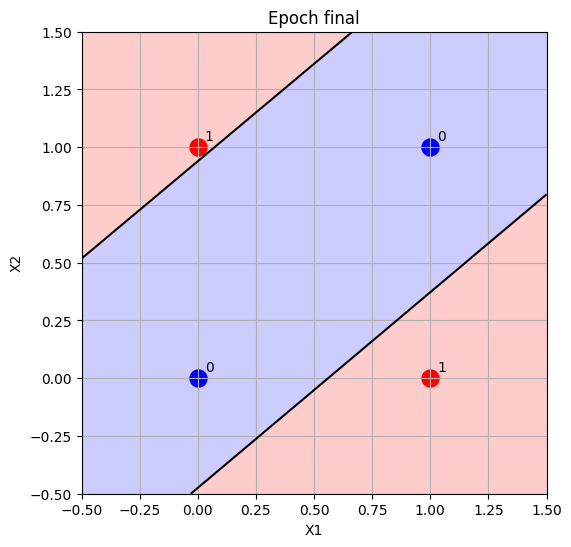

In [8]:
print("\nFinal Weights (Input->Hidden):")
print(weights_input_hidden)
print("\nFinal Weights (Hidden->Output):")
print(weights_hidden_output)

plot_boundary("final")
